# Revised GFDL-ESM4 sampling-sensitivity figure

# GFDL-ESM4 sampling sensitivity: analysis regions and volume-weighted MAE

Panel **a** shows the six analysis regions and the locations of the 2,000 added profiles in each regional deployment.

Panels **b-c** compare Ito (2024) RF and Ito (2022) OI using global, water-volume-weighted trend MAE for the upper 2000 m and below 2000 m. Bar annotations give the signed percentage change from the corresponding method's observed-sampling baseline; negative values indicate reduced MAE.


In [1]:
from pathlib import Path

import netCDF4 as nc
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.colors import BoundaryNorm, ListedColormap
from cartopy import crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
import sys
sys.path.append('/scratch/gpfs/GEOCLIM/LRGROUP/db9274/Analysis/Python_functions')
import basin_masks

PAPER = Path('/scratch/gpfs/LRGROUP/db9274/Variability_trends_EC/Paper_figures')
ARTIFICIAL = Path('/scratch/gpfs/LRGROUP/db9274/GFDL_ESM4_artificial_subsampling')
TREND_DIR = ARTIFICIAL / 'trend_comparison_outputs/fully_minus_gap_filled_trend_maps'
UNIFORM_CACHE = TREND_DIR / 'fully_minus_gap_filled_level_first_volume_weighted_1965_2021.nc'
SHIP_CACHE = TREND_DIR / 'ito2024_nn_original_4x_4xeast_8x.nc'
OI_UNIFORM_CACHE = TREND_DIR / 'ito2022_fully_minus_gap_filled_level_first_volume_weighted_1967_2019.nc'
OI_SHIP_CACHE = TREND_DIR / 'ito2022_original_4x_4xeast_8x.nc'
RF_SHIP_CACHE = TREND_DIR / 'ito2024_rf_original_4x_4xeast_8x.nc'
RF_05_CACHE = TREND_DIR / 'fully_minus_gap_filled_rf_pct05_level_first_volume_weighted_1965_2021.nc'
RF_30 = ARTIFICIAL / 'workflows/Ito_2024_NN/NETCDF/Artificial_subsampling_RF/GFDL_ESM4_pct30_r1i1p1f1_oxygen_gridded_RF.nc'
RF_30_CACHE = TREND_DIR / 'fully_minus_gap_filled_rf_pct30_level_first_volume_weighted_1965_2021.nc'
BASIN_MASK = Path('/scratch/gpfs/GEOCLIM/LRGROUP/db9274/Analysis/Variability_quantification/Ito_2022_OI_algorithm/optint_wod_o2/basin_mask_01.nc')
RAND_MASK = ARTIFICIAL / 'annual_masks/annual_mask_GFDL_ESM4_r1i1p1f1_randobs.nc'
RAND_NN = ARTIFICIAL / 'workflows/Ito_2024_NN/NETCDF/Artificial_subsampling_NN/GFDL_ESM4_randobs_r1i1p1f1_oxygen_gridded_NN.nc'
RAND_RF = ARTIFICIAL / 'workflows/Ito_2024_NN/NETCDF/Artificial_subsampling_RF/GFDL_ESM4_randobs_r1i1p1f1_oxygen_gridded_RF.nc'
RAND_OI = ARTIFICIAL / 'workflows/Ito_2022_OI/NETCDF/processed/o2_grid_1x1_GFDL_ESM4_randobs.nc'
RAND_TREND_CACHE = PAPER / 'cache_gfdl_esm4_randobs_trend_error_maps.nc'
FULL = PAPER / 'NETCDF/Fully_sampled_models_annual_o2/o2_1x1bin_GFDL_ESM4_r1i1p1f1.nc'
OBSERVED_O2 = Path('/scratch/gpfs/GEOCLIM/LRGROUP/db9274/Analysis/Variability_quantification/Ito_2022_OI_algorithm/Preprocessing_RB23/Monthly_subsampled_fields_1965_2021/o2/o2_1x1bin_GFDL_ESM4_r1i1p1f1.nc')

MASKS = {
    '4x': ARTIFICIAL / 'annual_masks/annual_added_shiptrack_mask_GFDL_ESM4_r1i1p1f1_ship4x.nc',
    '4x east-Pacific': ARTIFICIAL / 'annual_masks/annual_added_shiptrack_mask_GFDL_ESM4_r1i1p1f1_ship4x_eastpac.nc',
    '8x': ARTIFICIAL / 'annual_masks/annual_added_shiptrack_mask_GFDL_ESM4_r1i1p1f1_ship8x.nc',
}
UNIFORM_MASKS = {
    key: ARTIFICIAL / f'annual_masks/annual_mask_GFDL_ESM4_r1i1p1f1_pct{key}.nc'
    for key in ('05', '10', '30', '50', '70')
}
required = [UNIFORM_CACHE, SHIP_CACHE, OI_UNIFORM_CACHE, OI_SHIP_CACHE, RF_SHIP_CACHE, RF_05_CACHE, RF_30, BASIN_MASK, RAND_MASK, RAND_NN, RAND_RF, FULL, OBSERVED_O2, *MASKS.values(), *UNIFORM_MASKS.values()]
missing = [str(path) for path in required if not path.exists()]
assert not missing, 'Missing inputs:\n' + '\n'.join(missing)

plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 600, 'font.size': 10,
    'axes.titlesize': 11, 'axes.labelsize': 10, 'xtick.labelsize': 10,
    'ytick.labelsize': 10, 'legend.fontsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.linewidth': 0.7, 'pdf.fonttype': 42, 'ps.fonttype': 42,
    'savefig.facecolor': 'white', 'savefig.edgecolor': 'none',
})
BANDS = {'upper_2000m': (0.0, 2000.0), 'below_2000m': (2000.0, None)}
BAND_LABELS = {'upper_2000m': 'Upper 2000 m', 'below_2000m': 'Below 2000 m'}


In [2]:
def layer_edges(lev):
    lev = np.asarray(lev, dtype=float)
    edges = np.empty(lev.size + 1)
    edges[1:-1] = 0.5 * (lev[:-1] + lev[1:])
    edges[0] = max(0.0, lev[0] - 0.5 * (lev[1] - lev[0]))
    edges[-1] = lev[-1] + 0.5 * (lev[-1] - lev[-2])
    return edges

def band_thickness(lev, top, bottom):
    edges = layer_edges(lev)
    bottom = np.inf if bottom is None else float(bottom)
    return np.maximum(np.minimum(edges[1:], bottom) - np.maximum(edges[:-1], top), 0.0)

def grid_area(lat, lon, radius=6_371_000.0):
    lat_edges = np.empty(lat.size + 1)
    lat_edges[1:-1] = 0.5 * (lat[:-1] + lat[1:])
    lat_edges[0], lat_edges[-1] = -90.0, 90.0
    dlon = np.deg2rad(np.median(np.diff(lon)))
    strips = radius**2 * dlon * np.diff(np.sin(np.deg2rad(lat_edges)))
    return np.broadcast_to(strips[:, None], (lat.size, lon.size)).copy()

# Valid-ocean volume per horizontal column for each depth band.
with nc.Dataset(FULL) as ds:
    lev = np.asarray(ds.variables['lev'][:], dtype=float)
    lat = np.asarray(ds.variables['y'][:], dtype=float)
    lon = np.mod(np.asarray(ds.variables['x'][:], dtype=float), 360)
    o2 = ds.variables['o2']
    time_axis = o2.dimensions.index('time')
    index = [slice(None)] * o2.ndim
    index[time_axis] = 0
    snapshot = np.ma.filled(o2[tuple(index)], np.nan)
    remaining = [dim for dim in o2.dimensions if dim != 'time']
    snapshot = np.transpose(snapshot, [remaining.index('lev'), remaining.index('y'), remaining.index('x')])

area = grid_area(lat, lon)
column_volume = {}
for band, (top, bottom) in BANDS.items():
    dz = band_thickness(lev, top, bottom)[:, None, None]
    valid = np.isfinite(snapshot) & (dz > 0)
    column_volume[band] = np.sum(np.where(valid, dz * area[None, :, :], 0.0), axis=0)

# Six-basin surface mask: Pacific=2 and Indian=3. Restrict each to the
# tropical latitude bounds used by the ship-track generation workflow.
with xr.open_dataset(BASIN_MASK) as basin_ds:
    basin = basin_ds.basin_mask.isel(depth=0).load()
basin = basin.assign_coords(lon=np.mod(basin.lon, 360)).sortby('lon')
basin_values = basin.values
lat2d = np.broadcast_to(lat[:, None], basin_values.shape)
tropical_ship_region = (
    ((basin_values == 2) & (lat2d >= -20) & (lat2d <= 20)) |
    ((basin_values == 3) & (lat2d >= -30) & (lat2d <= 30))
)

def volume_weighted_mae(field, band, region=None):
    values = np.asarray(field, dtype=float)
    weights = column_volume[band]
    valid = np.isfinite(values) & (weights > 0)
    if region is not None:
        valid &= region
    return np.average(np.abs(values[valid]), weights=weights[valid])


def read_years(ds):
    return np.array([d.year for d in nc.num2date(
        ds.variables['time'][:], ds.variables['time'].units,
        calendar=getattr(ds.variables['time'], 'calendar', 'standard'))], dtype=int)

def calculate_level_trends(path, start, end):
    wanted = np.arange(start, end + 1)
    with nc.Dataset(path) as ds:
        years = read_years(ds)
        zn = 'lev' if 'lev' in ds.variables else 'depth'
        yn = 'y' if 'y' in ds.variables else 'lat'
        xn = 'x' if 'x' in ds.variables else 'lon'
        z=np.asarray(ds.variables[zn][:],float); yy=np.asarray(ds.variables[yn][:],float)
        xx=np.mod(np.asarray(ds.variables[xn][:],float),360)
        v=ds.variables['o2']; ta=v.dimensions.index('time')
        rem=[d for d in v.dimensions if d!='time']; order=[rem.index(d) for d in (zn,yn,xn)]
        shape=(z.size,yy.size,xx.size)
        a={k:np.zeros(shape,float) for k in ('n','sx','sy','sxx','sxy')}
        for year in wanted:
            total=np.zeros(shape,float); count=np.zeros(shape,np.uint8)
            for ti in np.flatnonzero(years==year):
                idx=[slice(None)]*v.ndim; idx[ta]=int(ti)
                x=np.ma.filled(v[tuple(idx)],np.nan).astype(float); x[x>1e19]=np.nan
                x=np.transpose(x,order); good=np.isfinite(x)
                total+=np.where(good,x,0); count+=good
            annual=np.divide(total,count,out=np.full(shape,np.nan),where=count>0)
            good=np.isfinite(annual)
            a['n']+=good; a['sx']+=np.where(good,year,0); a['sy']+=np.where(good,annual,0)
            a['sxx']+=np.where(good,year*year,0); a['sxy']+=np.where(good,year*annual,0)
        den=a['n']*a['sxx']-a['sx']**2
        trend=np.divide(a['n']*a['sxy']-a['sx']*a['sy'],den,out=np.full(shape,np.nan),
                        where=(a['n']==wanted.size)&(den!=0))*10
    return z,yy,xx,trend

def difference_maps(full_trend, mapped_trend, z):
    diff=full_trend-mapped_trend; result={}
    for band,(top,bottom) in BANDS.items():
        dz=band_thickness(z,top,bottom)[:,None,None]
        valid=np.isfinite(diff)&(dz>0)
        den=np.sum(np.where(valid,dz,0),axis=0)
        num=np.nansum(np.where(valid,diff*dz,np.nan),axis=0)
        result[band]=np.divide(num,den,out=np.full_like(num,np.nan),where=den>0)
    return result

if RAND_TREND_CACHE.exists():
    rand_trends=xr.open_dataset(RAND_TREND_CACHE).load()
else:
    rand_trends=xr.Dataset(coords={'lat':lat,'lon':lon})
random_products={'rf':(RAND_RF,1965,2021)}
if RAND_OI.exists():
    random_products['oi']=(RAND_OI,1967,2019)
changed=False; full_trends={}
for method,(path,start,end) in random_products.items():
    if all(f'randobs_{method}_{band}' in rand_trends for band in BANDS):
        continue
    if (start,end) not in full_trends:
        full_trends[start,end]=calculate_level_trends(FULL,start,end)
    z0,y0,x0,ft=full_trends[start,end]
    z1,y1,x1,mt=calculate_level_trends(path,start,end)
    if not (np.allclose(z0,z1) and np.allclose(y0,y1) and np.allclose(x0,x1)):
        raise ValueError(f'Coordinate mismatch for {path}')
    for band,values in difference_maps(ft,mt,z0).items():
        rand_trends[f'randobs_{method}_{band}']=(('lat','lon'),values.astype('float32'))
    changed=True
if changed:
    tmp=RAND_TREND_CACHE.with_suffix('.nc.tmp')
    rand_trends.to_netcdf(tmp,encoding={v:{'zlib':True,'complevel':4} for v in rand_trends.data_vars})
    tmp.replace(RAND_TREND_CACHE)

oi_uniform = xr.open_dataset(OI_UNIFORM_CACHE)
oi_ship = xr.open_dataset(OI_SHIP_CACHE)
rf_ship = xr.open_dataset(RF_SHIP_CACHE)
rf05 = xr.open_dataset(RF_05_CACHE)
if RF_30_CACHE.exists():
    rf30 = xr.open_dataset(RF_30_CACHE)
else:
    z0, y0, x0, full_30_trend = calculate_level_trends(FULL, 1965, 2021)
    z1, y1, x1, mapped_30_trend = calculate_level_trends(RF_30, 1965, 2021)
    if not (np.allclose(z0, z1) and np.allclose(y0, y1) and np.allclose(x0, x1)):
        raise ValueError('RF 30% coordinates do not match fully sampled coordinates')
    rf30 = xr.Dataset(coords={'lat': y0, 'lon': x0})
    for band, values in difference_maps(full_30_trend, mapped_30_trend, z0).items():
        rf30[f'fully_minus_gap_filled_rf30_{band}'] = (('lat', 'lon'), values.astype('float32'))
    rf30.to_netcdf(RF_30_CACHE, encoding={v: {'zlib': True, 'complevel': 4} for v in rf30.data_vars})
    print(f'Saved {RF_30_CACHE}')

with xr.open_dataset(RAND_MASK) as random_mask:
    random_pct = {
        'upper_2000m': float(random_mask.achieved_upper_0_2000_fraction.mean()) * 100,
        'below_2000m': float(random_mask.achieved_below_2000_fraction.mean()) * 100,
    }
original_pct = random_pct.copy()
uniform_percent = {}
for band in BANDS:
    uniform_percent[band] = {}
    for key, path in UNIFORM_MASKS.items():
        with xr.open_dataset(path) as mask:
            name = 'upper_0_2000_fraction' if band == 'upper_2000m' else 'below_2000_fraction'
            uniform_percent[band][key] = float(mask[name].mean()) * 100

rows = []
uniform_sources = {'Ito (2022) OI': oi_uniform}
for method, dataset in uniform_sources.items():
    for band in BANDS:
        rows.append({'family': 'uniform', 'method': method, 'band': band, 'case': 'Original',
                     'observed_percent': original_pct[band],
                     'mae': volume_weighted_mae(dataset[f'fully_minus_gap_filled_original_{band}'], band)})
        for key in UNIFORM_MASKS:
            rows.append({'family': 'uniform', 'method': method, 'band': band, 'case': f'{int(key)}%',
                         'observed_percent': uniform_percent[band][key],
                         'mae': volume_weighted_mae(dataset[f'fully_minus_gap_filled_{key}_{band}'], band)})

# Random-global sampling has the same observed volume as original sampling.
for method, key in [('Ito (2022) OI', 'oi'), ('Ito (2024) RF', 'rf')]:
    for band in BANDS:
        name = f'randobs_{key}_{band}'
        if name in rand_trends:
            rows.append({'family':'uniform','method':method,'band':band,'case':'Random global',
                         'observed_percent':random_pct[band],
                         'mae':volume_weighted_mae(rand_trends[name],band)})

# RF uniform-coverage cases used in the revised comparison.
for band in BANDS:
    rows.extend([
        {'family': 'uniform', 'method': 'Ito (2024) RF', 'band': band, 'case': 'Original',
         'observed_percent': original_pct[band],
         'mae': volume_weighted_mae(rf_ship[f'fully_minus_gap_filled_original_{band}'], band)},
        {'family': 'uniform', 'method': 'Ito (2024) RF', 'band': band, 'case': '5%',
         'observed_percent': uniform_percent[band]['05'],
         'mae': volume_weighted_mae(rf05[f'fully_minus_gap_filled_rf05_{band}'], band)},
        {'family': 'uniform', 'method': 'Ito (2024) RF', 'band': band, 'case': '30%',
         'observed_percent': uniform_percent[band]['30'],
         'mae': volume_weighted_mae(rf30[f'fully_minus_gap_filled_rf30_{band}'], band)},
    ])

ship_sources = {'Ito (2022) OI': oi_ship, 'Ito (2024) RF': rf_ship}
for method, dataset in ship_sources.items():
    for band in BANDS:
        for key, label in [('original', 'Original'), ('ship4x', '4x'),
                           ('ship4x_eastpac', '4x east-Pacific'), ('ship8x', '8x')]:
            rows.append({
                'family': 'ship tracks', 'method': method, 'band': band, 'case': label,
                'observed_percent': np.nan,
                'mae': volume_weighted_mae(
                    dataset[f'fully_minus_gap_filled_{key}_{band}'], band
                ),
            })

metrics = pd.DataFrame(rows)
METRICS_CSV = PAPER / 'gfdl_esm4_sampling_sensitivity_volume_weighted_mae.csv'
metrics.to_csv(METRICS_CSV, index=False)
metrics


,family,method,band,case,observed_percent,mae
0,uniform,Ito (2022) OI,upper_2000m,Original,4.438417,0.348762
1,uniform,Ito (2022) OI,upper_2000m,5%,5.000047,0.203859
2,uniform,Ito (2022) OI,upper_2000m,10%,10.000031,0.197628
3,uniform,Ito (2022) OI,upper_2000m,30%,30.000037,0.190313
4,uniform,Ito (2022) OI,upper_2000m,50%,50.000050,0.188951
5,uniform,Ito (2022) OI,upper_2000m,70%,70.000041,0.188711
6,uniform,Ito (2022) OI,below_2000m,Original,1.390341,0.283999
7,uniform,Ito (2022) OI,below_2000m,5%,5.000076,0.107560
8,uniform,Ito (2022) OI,below_2000m,10%,10.000084,0.102669
9,uniform,Ito (2022) OI,below_2000m,30%,30.000091,0.097153


In [3]:
# Regional nested-profile masks and reconstructed-trend error caches.
REGIONAL_MASK_DIR = ARTIFICIAL / 'regional_shiptrack_masks'
REGIONAL_MAE_DIR = ARTIFICIAL / 'mae_comparison_outputs'
REGIONAL_MASKS = {
    (region, count): REGIONAL_MASK_DIR / f'shiptrack_{region}_{count:04d}_profiles.nc'
    for region in ('tropical', 'extratropical', 'southern_ocean')
    for count in (2000,)
}
REGIONAL_CACHES = {
    ('Ito (2024) RF', 'upper_2000m'): REGIONAL_MAE_DIR / 'regional_upper2000m_mae_1965_2021.nc',
    ('Ito (2024) RF', 'below_2000m'): REGIONAL_MAE_DIR / 'regional_below2000m_mae_1965_2021.nc',
    ('Ito (2022) OI', 'upper_2000m'): REGIONAL_MAE_DIR / 'regional_upper2000m_mae_1967_2019.nc',
    ('Ito (2022) OI', 'below_2000m'): REGIONAL_MAE_DIR / 'regional_below2000m_mae_1967_2019.nc',
}
missing_regional = [str(x) for x in [*REGIONAL_MASKS.values(), *REGIONAL_CACHES.values()] if not x.exists()]
assert not missing_regional, 'Run the regional MAE notebooks first:\n' + '\n'.join(missing_regional)

# Locations of the 2,000 added profiles in each region.
regional_points = []
for region in ('tropical', 'extratropical', 'southern_ocean'):
    with xr.open_dataset(REGIONAL_MASKS[(region, 2000)]) as mask:
        order = mask.station_order.values
        yy, xx = np.where(order > 0)
        regional_points.append((mask.x.values[xx], mask.y.values[yy]))

# Annual observed-volume fractions use the same depth bands, 3-D cell-volume
# weights, and annual averaging as the historical and random-global cases.
# The original oxygen mask reproduces the historical target fractions stored in
# RAND_MASK; check this before using it to add the regional profile columns.
coverage_weights = np.diff(layer_edges(lev))[:, None, None] * np.cos(np.deg2rad(lat))[None, :, None]
full_valid = np.isfinite(snapshot)
deployment_valid = {}
for region in ('tropical', 'extratropical', 'southern_ocean'):
    with xr.open_dataset(REGIONAL_MASKS[(region, 2000)]) as mask:
        deployment_valid[region] = mask.deployment_mask.values.astype(bool)[None, :, :] & full_valid
with xr.open_dataset(RAND_MASK) as mask:
    target_fractions = {
        'upper_2000m': mask.target_upper_0_2000_fraction.values,
        'below_2000m': mask.target_below_2000_fraction.values,
    }
regional_annual_percent = {band: {region: [] for region in deployment_valid} for band in BANDS}
with nc.Dataset(OBSERVED_O2) as ds:
    observed_o2 = ds.variables['o2']
    assert observed_o2.shape[0] == 12 * len(target_fractions['upper_2000m'])
    for year_index in range(observed_o2.shape[0] // 12):
        observed = np.zeros(full_valid.shape, dtype=bool)
        for month_index in range(12 * year_index, 12 * (year_index + 1)):
            observed |= np.isfinite(np.ma.filled(observed_o2[month_index], np.nan))
        for band, levels in (('upper_2000m', lev <= 2000), ('below_2000m', lev > 2000)):
            denominator = np.sum((coverage_weights * full_valid)[levels])
            baseline = np.sum((coverage_weights * observed)[levels]) / denominator
            np.testing.assert_allclose(baseline, target_fractions[band][year_index], atol=1e-4)
            for region, additions in deployment_valid.items():
                fraction = np.sum((coverage_weights * (observed | additions))[levels]) / denominator
                regional_annual_percent[band][region].append(100 * fraction)
regional_percent = {
    band: {region: float(np.mean(values)) for region, values in cases.items()}
    for band, cases in regional_annual_percent.items()
}

regional_rows = []
for (method, band), cache_path in REGIONAL_CACHES.items():
    with xr.open_dataset(cache_path) as ds:
        weights = ds.column_volume.values
        for region in ('tropical', 'extratropical', 'southern_ocean'):
            for count in (2000,):
                field = ds[f'mae_{region}_{count}'].values
                valid = np.isfinite(field) & (weights > 0)
                regional_rows.append({
                    'method': method, 'band': band, 'region': region,
                    'profiles': count,
                    'global_mae': np.average(field[valid], weights=weights[valid]),
                })
regional_metrics = pd.DataFrame(regional_rows)
REGIONAL_METRICS_CSV = PAPER / 'gfdl_esm4_regional_sampling_global_volume_weighted_mae.csv'
regional_metrics.to_csv(REGIONAL_METRICS_CSV, index=False)
regional_metrics


,method,band,region,profiles,global_mae
0,Ito (2024) RF,upper_2000m,tropical,2000,0.201436
1,Ito (2024) RF,upper_2000m,extratropical,2000,0.238204
2,Ito (2024) RF,upper_2000m,southern_ocean,2000,0.263338
3,Ito (2024) RF,below_2000m,tropical,2000,0.115031
4,Ito (2024) RF,below_2000m,extratropical,2000,0.172306
5,Ito (2024) RF,below_2000m,southern_ocean,2000,0.196754
6,Ito (2022) OI,upper_2000m,tropical,2000,0.329733
7,Ito (2022) OI,upper_2000m,extratropical,2000,0.321470
8,Ito (2022) OI,upper_2000m,southern_ocean,2000,0.320262
9,Ito (2022) OI,below_2000m,tropical,2000,0.202444


Saved /scratch/gpfs/LRGROUP/db9274/Variability_trends_EC/Paper_figures_p2/Figures/GFDL_ESM4_sampling_sensitivity_six_panel.pdf


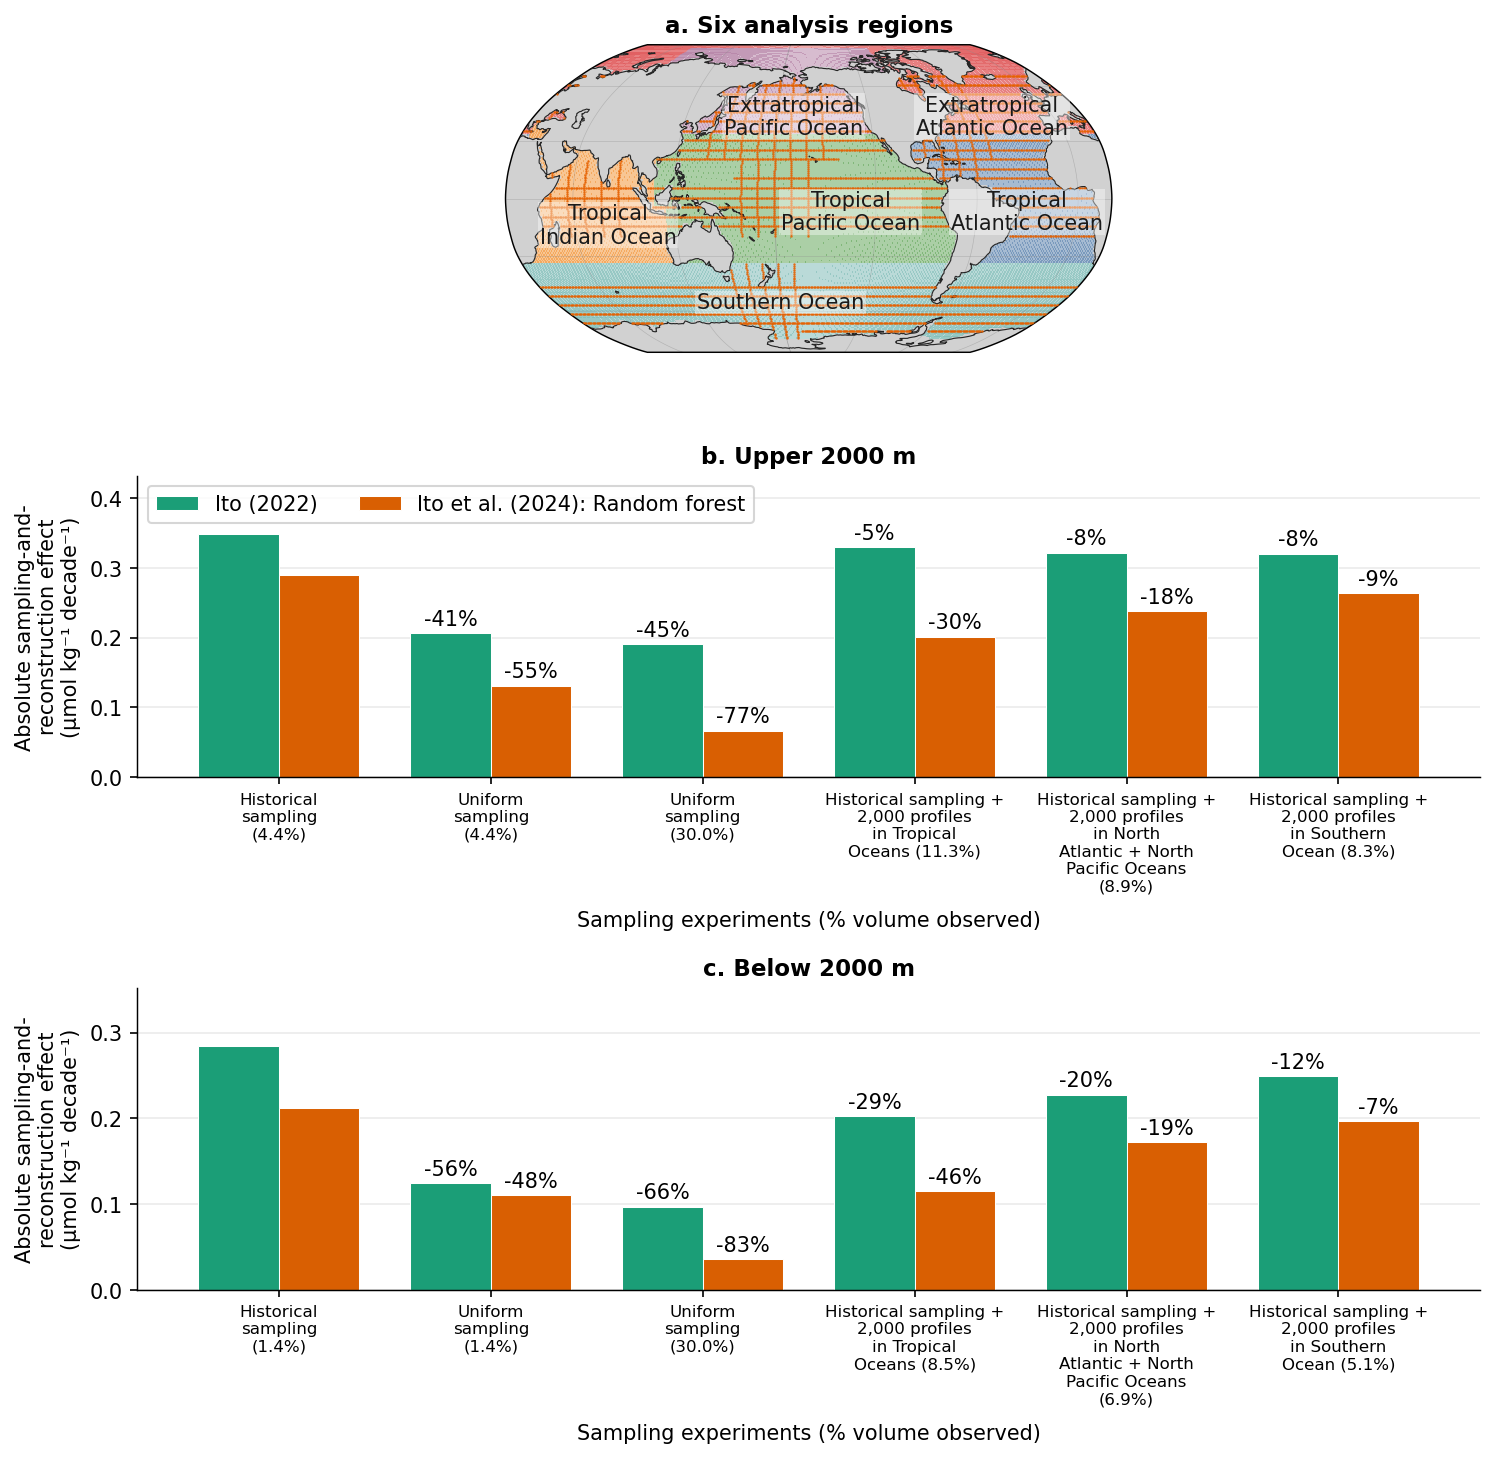

In [4]:
fig = plt.figure(figsize=(10, 10))
gs = fig.add_gridspec(2, 1, height_ratios=(0.68, 1.8),
                      left=0.09, right=0.985, bottom=0.14, top=0.97, hspace=0.22)
projection = ccrs.Robinson(central_longitude=200)
top = gs[0].subgridspec(1, 1)
ax_a = fig.add_subplot(top[0, 0], projection=projection)
bottom = gs[1].subgridspec(2, 1, hspace=0.70)
ax_c = fig.add_subplot(bottom[0])
ax_d = fig.add_subplot(bottom[1])

REGION_MAP_LABELS = {'Atlantic': 'Tropical\nAtlantic Ocean',
                     'Pacific': 'Tropical\nPacific Ocean',
                     'Indian': 'Tropical\nIndian Ocean',
                     'Southern': 'Southern Ocean',
                     'North Atlantic': 'North\nAtlantic Ocean',
                     'North Pacific': 'North\nPacific Ocean'}
REGION_MAP_COLORS = dict(zip(
    ['Atlantic', 'Pacific', 'Indian', 'Southern', 'North Atlantic', 'North Pacific'],
    ['#4E79A7', '#59A14F', '#F28E2B', '#76B7B2', '#E15759', '#B07AA1']))
REGION_MAP_LABEL_POINTS = {'Atlantic': (330, -7), 'Pacific': (225, -7),
                           'Indian': (80, -14), 'Southern': (180, -55),
                           'North Atlantic': (320, 43), 'North Pacific': (190, 43)}
with xr.open_dataset(FULL) as ds:
    variable = 'o2' if 'o2' in ds.data_vars else next(iter(ds.data_vars))
    field = ds[variable]
    for dim in ('time', 'lev', 'depth'):
        if dim in field.dims: field = field.isel({dim: 0})
    if 'x' in field.dims: field = field.rename({'x': 'lon'})
    if 'y' in field.dims: field = field.rename({'y': 'lat'})
    field = field.load()
land_mask = field.where(np.isfinite(field))
masks = basin_masks.create_basin_mask(land_mask, nbasins=6)
region = xr.full_like(masks[0], np.nan, dtype=float)
for index, mask in enumerate(masks, start=1):
    region = region.where(~(mask.fillna(0) > 0), float(index))
supplementary_basins = ['Atlantic', 'Pacific', 'Indian', 'Southern', 'North Atlantic', 'North Pacific']
region_cmap = ListedColormap([REGION_MAP_COLORS[b] for b in supplementary_basins])
region_norm = BoundaryNorm(np.arange(0.5, 7.5), region_cmap.N)
land = xr.where(np.isfinite(region), np.nan, 1.0)
ax_a.pcolormesh(region.lon, region.lat, land, cmap=ListedColormap(['0.82']),
                shading='nearest', transform=ccrs.PlateCarree(), rasterized=True, zorder=0)
ax_a.pcolormesh(region.lon, region.lat, region, cmap=region_cmap, norm=region_norm,
                shading='nearest', transform=ccrs.PlateCarree(), rasterized=True, alpha=0.5, zorder=1)
for i, (xx, yy) in enumerate(regional_points):
    ax_a.scatter(xx, yy, s=1.3, linewidths=0, alpha=0.9, transform=ccrs.PlateCarree(),
                 zorder=4, label='2,000 added profiles' if i == 0 else None, color='#e66101')
ax_a.set_global(); ax_a.add_feature(cfeature.LAND, facecolor='0.82', edgecolor='none', zorder=2)
ax_a.coastlines(linewidth=0.55, color='0.15', zorder=3)
ax_a.gridlines(linewidth=0.3, color='0.55', alpha=0.45)
for basin_name in supplementary_basins:
    xx, yy = REGION_MAP_LABEL_POINTS[basin_name]
    ax_a.text(xx, yy, REGION_MAP_LABELS[basin_name], transform=ccrs.PlateCarree(),
              ha='center', va='center', fontsize=10, color='0.10',
              bbox=dict(facecolor='white', edgecolor='none', alpha=0.4, pad=0.8), zorder=5)
ax_a.set_title('a. Six analysis regions', loc='center', fontweight='bold')

# b,c: six experiment groups x two reconstruction methods = 12 bars per panel.
experiment_specs = [
    ('Original', 'standard', 'uniform', 'Original'),
    ('Uniform sampling\n(same coverage)', 'standard', 'uniform', 'Random global'),
    ('30% sampling\ncoverage', 'standard', 'uniform', '30%'),
    ('Tropical\n+2,000', 'regional', 'tropical', 2000),
    ('North\n+2,000', 'regional', 'extratropical', 2000),
    ('Southern Ocean\n+2,000', 'regional', 'southern_ocean', 2000),
]
method_styles = {
    'Ito (2022) OI': dict(color='#1b9e77', label='Ito (2022)'),
    'Ito (2024) RF': dict(color='#d95f02', label='Ito et al. (2024): Random forest'),
}
x = np.arange(len(experiment_specs)); width = 0.38
for ax, band, panel in ((ax_c, 'upper_2000m', 'b'), (ax_d, 'below_2000m', 'c')):
    for offset, (method, style) in zip((-width / 2, width / 2), method_styles.items()):
        baseline_match = metrics.query(
            "method == @method and band == @band and family == 'uniform' and case == 'Original'"
        )
        baseline = float(baseline_match.mae.iloc[0])
        values = []
        for _, source, family_or_region, case_or_profiles in experiment_specs:
            if source == 'standard':
                match = metrics.query(
                    'method == @method and band == @band and family == @family_or_region and case == @case_or_profiles'
                )
                values.append(float(match.mae.iloc[0]) if len(match) else np.nan)
            else:
                match = regional_metrics.query(
                    'method == @method and band == @band and region == @family_or_region and profiles == @case_or_profiles'
                )
                values.append(float(match.global_mae.iloc[0]) if len(match) else np.nan)
        bars = ax.bar(x + offset, values, width=width, color=style['color'],
                      edgecolor='white', linewidth=0.5, label=style['label'])
        changes = [100 * (value - baseline) / baseline for value in values]
        for experiment_index, (bar, change) in enumerate(zip(bars, changes)):
            if experiment_index > 0 and np.isfinite(change):
                ax.annotate(f'{change:+.0f}%',
                            (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                            xytext=(0, 2), textcoords='offset points',
                            ha='center', va='bottom', rotation=0, fontsize=10)
    ax.set_xticks(x)
    sublabels = [
        f'Historical\nsampling\n({original_pct[band]:.1f}%)',
        f'Uniform\nsampling\n({random_pct[band]:.1f}%)',
        f'Uniform\nsampling\n({uniform_percent[band]["30"]:.1f}%)',
        f'Historical sampling +\n2,000 profiles\nin Tropical\nOceans ({regional_percent[band]["tropical"]:.1f}%)',
        f'Historical sampling +\n2,000 profiles\nin North\nAtlantic + North\nPacific Oceans\n({regional_percent[band]["extratropical"]:.1f}%)',
        f'Historical sampling +\n2,000 profiles\nin Southern\nOcean ({regional_percent[band]["southern_ocean"]:.1f}%)',
    ]
    ax.set_xticklabels(sublabels, fontsize=8)
    ax.set_xlabel('Sampling experiments (% volume observed)', labelpad=8)
    ax.set_ylabel('Absolute sampling-and-\nreconstruction effect\n(µmol kg⁻¹ decade⁻¹)')
    ax.set_title(f'{panel}. {BAND_LABELS[band]}',
                 loc='center', fontweight='bold')
    ax.grid(axis='y', alpha=0.25); ax.set_axisbelow(True)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.18)
ax_c.legend(ncol=2, loc='upper left', frameon=True)

fig.align_ylabels([ax_c, ax_d])
OUTPUT_DIR = Path('/scratch/gpfs/LRGROUP/db9274/Variability_trends_EC/Paper_figures_p2/Figures'); OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_PDF = OUTPUT_DIR / 'GFDL_ESM4_sampling_sensitivity_six_panel.pdf'
fig.savefig(FIG_PDF, facecolor='white')
print(f'Saved {FIG_PDF}')
plt.show()


## Consolidated Ito (2024) RF figure

This separate figure removes panel a, combines the upper- and below-2000 m results from panels b-c, excludes Ito (2022), and includes the 2,000-added-profile experiments.

Saved /scratch/gpfs/LRGROUP/db9274/Variability_trends_EC/Paper_figures_p2/Figures/GFDL_ESM4_sampling_sensitivity_RF_consolidated.pdf


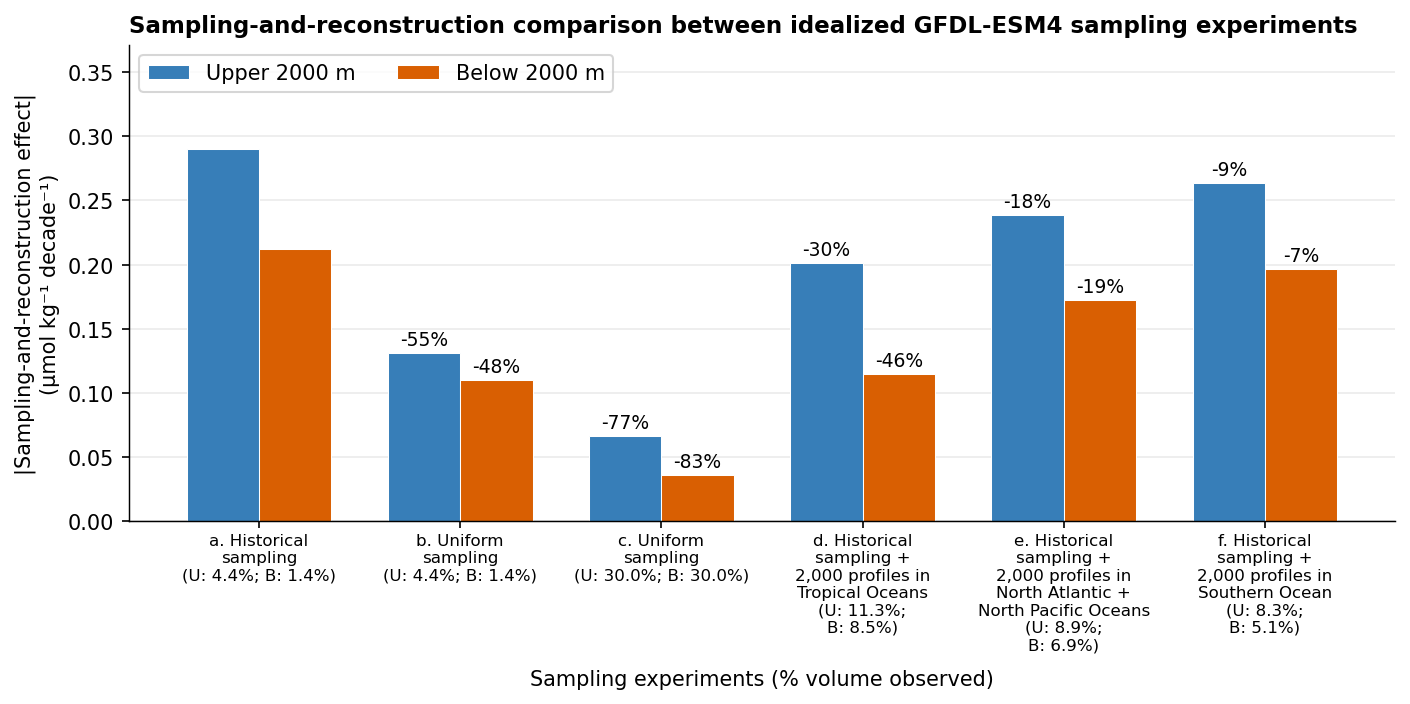

In [5]:
# Consolidated b-c figure: Ito (2024) RF only.
rf_experiment_specs = [
    ('Original', 'standard', 'uniform', 'Original'),
    ('Uniform sampling', 'standard', 'uniform', 'Random global'),
    ('30% sampling coverage', 'standard', 'uniform', '30%'),
    ('Tropical +2,000', 'regional', 'tropical', 2000),
    ('North +2,000', 'regional', 'extratropical', 2000),
    ('Southern Ocean +2,000', 'regional', 'southern_ocean', 2000),
]
rf_method = 'Ito (2024) RF'
rf_values = {}
for band in BANDS:
    baseline = float(metrics.query(
        "method == @rf_method and band == @band and family == 'uniform' and case == 'Original'"
    ).mae.iloc[0])
    values = []
    for _, source, family_or_region, case_or_profiles in rf_experiment_specs:
        if source == 'standard':
            match = metrics.query(
                'method == @rf_method and band == @band and family == @family_or_region and case == @case_or_profiles'
            )
            values.append(float(match.mae.iloc[0]) if len(match) else np.nan)
        else:
            match = regional_metrics.query(
                'method == @rf_method and band == @band and region == @family_or_region and profiles == @case_or_profiles'
            )
            values.append(float(match.global_mae.iloc[0]) if len(match) else np.nan)
    rf_values[band] = np.asarray(values)

fig_consolidated, ax_consolidated = plt.subplots(figsize=(9.5, 4.8))
x = np.arange(len(rf_experiment_specs))
width = 0.36
colors = {'upper_2000m': '#377eb8', 'below_2000m': '#d95f02'}
bars = {}
for offset, band in zip((-width / 2, width / 2), BANDS):
    bars[band] = ax_consolidated.bar(
        x + offset, rf_values[band], width=width,
        color=colors[band], edgecolor='white', linewidth=0.5,
        label=BAND_LABELS[band],
    )

sublabels = [
    f'a. Historical\nsampling\n(U: {original_pct["upper_2000m"]:.1f}%; B: {original_pct["below_2000m"]:.1f}%)',
    f'b. Uniform\nsampling\n(U: {random_pct["upper_2000m"]:.1f}%; B: {random_pct["below_2000m"]:.1f}%)',
    f'c. Uniform\nsampling\n(U: {uniform_percent["upper_2000m"]["30"]:.1f}%; B: {uniform_percent["below_2000m"]["30"]:.1f}%)',
    f'd. Historical\nsampling +\n2,000 profiles in\nTropical Oceans\n(U: {regional_percent["upper_2000m"]["tropical"]:.1f}%;\nB: {regional_percent["below_2000m"]["tropical"]:.1f}%)',
    f'e. Historical\nsampling +\n2,000 profiles in\nNorth Atlantic +\nNorth Pacific Oceans\n(U: {regional_percent["upper_2000m"]["extratropical"]:.1f}%;\nB: {regional_percent["below_2000m"]["extratropical"]:.1f}%)',
    f'f. Historical\nsampling +\n2,000 profiles in\nSouthern Ocean\n(U: {regional_percent["upper_2000m"]["southern_ocean"]:.1f}%;\nB: {regional_percent["below_2000m"]["southern_ocean"]:.1f}%)',
]
ax_consolidated.set_xticks(x, sublabels)
ax_consolidated.tick_params(axis='x', labelsize=8, pad=2)
ax_consolidated.set_xlabel('Sampling experiments (% volume observed)', labelpad=8)
ax_consolidated.set_ylabel('|Subsampling-reconstruction error|\n(µmol kg⁻¹ decade⁻¹)')
ax_consolidated.set_title('Subsampling-reconstruction errors (absolute local errors spatially averaged)\nfor GFDL-ESM4 sampling experiments', loc='center', fontweight='bold')
ax_consolidated.grid(axis='y', alpha=0.25)
ax_consolidated.set_axisbelow(True)
ax_consolidated.set_ylim(0, ax_consolidated.get_ylim()[1] * 1.22)
for band in BANDS:
    baseline = rf_values[band][0]
    changes = 100 * (rf_values[band] - baseline) / baseline
    for index, (bar, change) in enumerate(zip(bars[band], changes)):
        if index > 0 and np.isfinite(change):
            ax_consolidated.annotate(
                f'{change:+.0f}%',
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 2), textcoords='offset points',
                ha='center', va='bottom', fontsize=9,
            )
ax_consolidated.legend(frameon=True, ncol=2, loc='upper left')
fig_consolidated.tight_layout()
CONSOLIDATED_PDF = Path('/scratch/gpfs/LRGROUP/db9274/Variability_trends_EC/Paper_figures_p2/Figures') / 'GFDL_ESM4_sampling_sensitivity_RF_consolidated.pdf'
fig_consolidated.savefig(CONSOLIDATED_PDF, facecolor='white')
print(f'Saved {CONSOLIDATED_PDF}')
plt.show()


**GFDL_ESM4_sampling_sensitivity_six_panel.pdf**

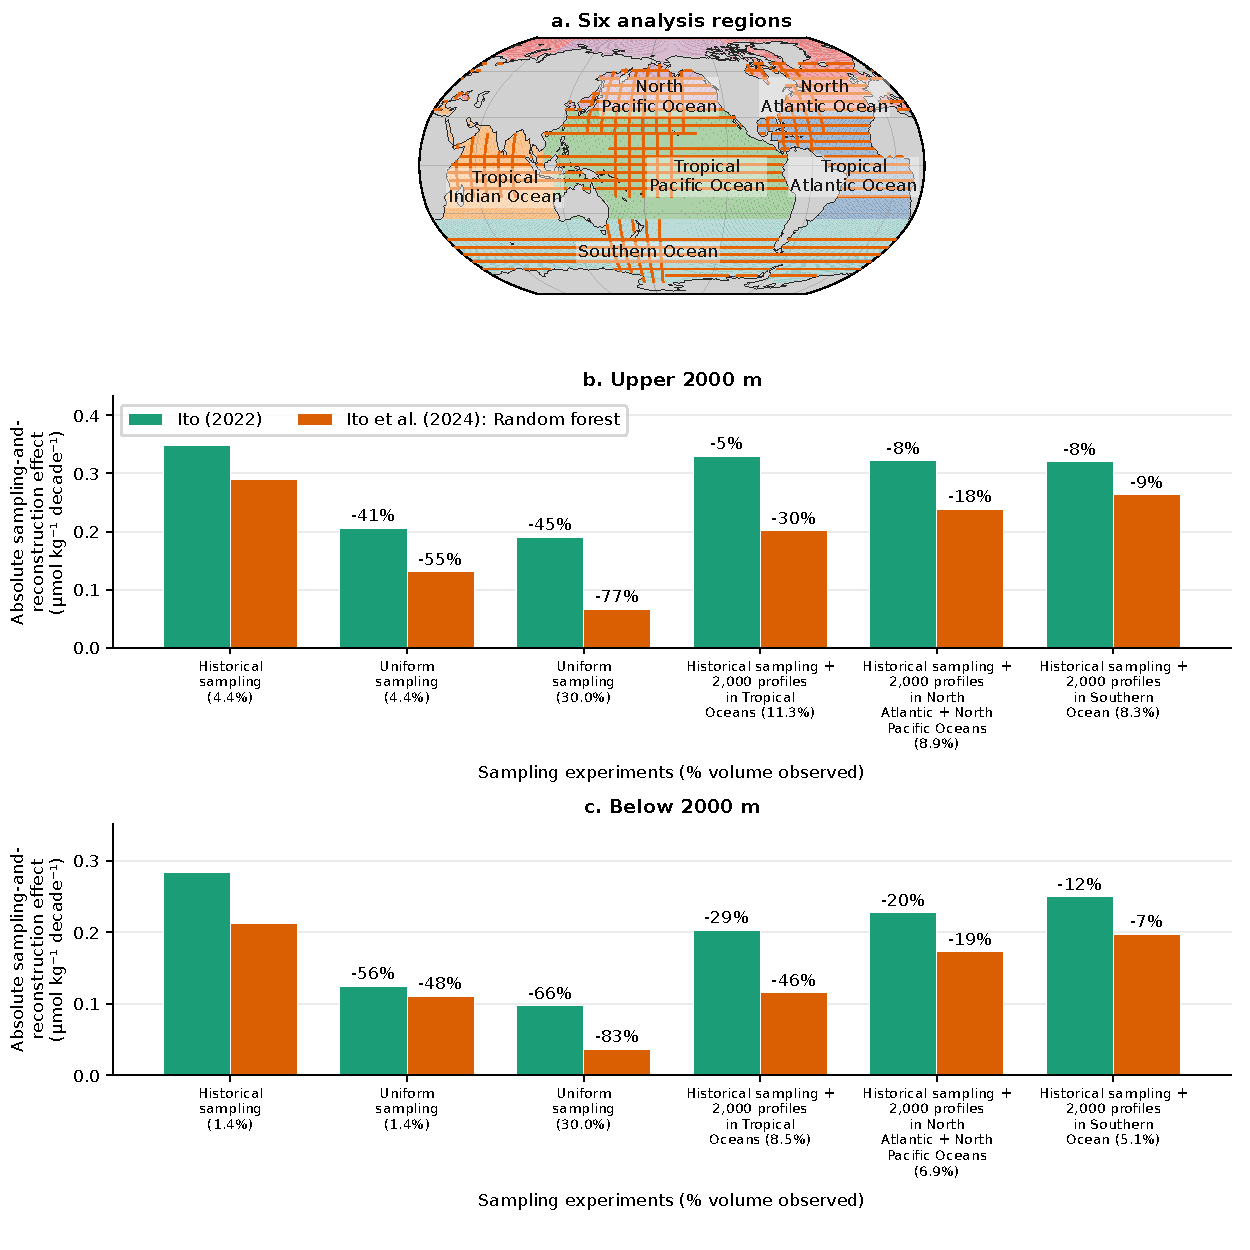

**GFDL_ESM4_sampling_sensitivity_RF_consolidated.pdf**

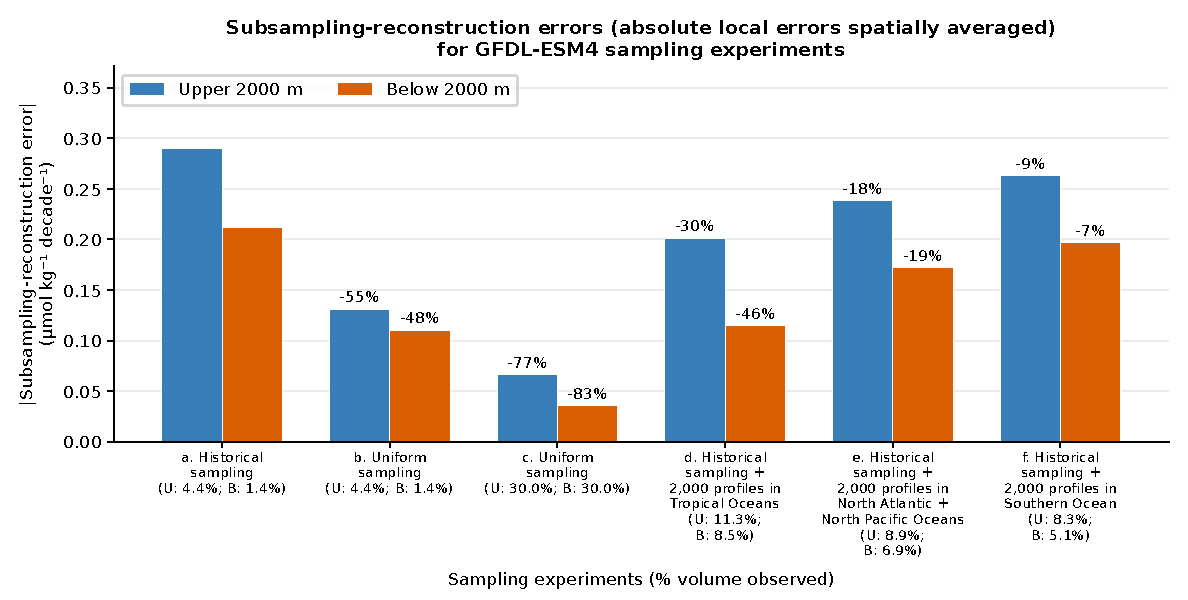

In [6]:
# Show the saved paper PDF in GitHub's notebook viewer.
from pathlib import Path
from tempfile import TemporaryDirectory
from IPython.display import Image, Markdown, display
import subprocess

PDF_PREVIEWS = tuple(Path(name) for name in ['Figures/GFDL_ESM4_sampling_sensitivity_six_panel.pdf', 'Figures/GFDL_ESM4_sampling_sensitivity_RF_consolidated.pdf'])

for pdf in PDF_PREVIEWS:
    display(Markdown(f"**{pdf.name}**"))
    with TemporaryDirectory() as temporary_dir:
        preview = Path(temporary_dir) / "preview.png"
        subprocess.run(["gs", "-q", "-dSAFER", "-dBATCH", "-dNOPAUSE",
                        "-sDEVICE=png16m", "-r125", "-dFirstPage=1", "-dLastPage=1",
                        f"-sOutputFile={preview}", str(pdf)], check=True)
        display(Image(filename=str(preview)))
